In [ ]:
# Cluster is a group of similar data grouped together , no lables no predictions 

# types of clusters : 
# 1. centroied based cluster 
#     -- KMeans
# 2. Tree Based cluster ( Hierarchical cluster ) : 
#     -- Agglomerative Clustering
# 3. Density based Cluster : 
#     -- DBSCAN

In [ ]:
# KMEANS


# K means groups data points into k clusters such that point in the same cluster are as similar as possiabl 
# - Who suppose to give k value : Modle or Bussiness owner. 

# How the K Means Algo works
# step1 : choose k value k = 3 
# step2 : place k random centroids ( but these are temp centroids points ) 
# step3 : Assign points to nearest centroid 
# step4 : recalculate centroids 
# step5 : repeat step 3 and 4 intil center points stop moving. 

# In this way the kmeans works

# Note : 
# Scaling is mandatory for kmeans 
# It is outlier senstive

# Evaluation of Clustering 
# 1. Inertia : Inertia is the total distance of all points from their respective cluster centrers.
#     note : It measures how compact the clusters are.

# 2. Silhouette Score : 

# Real time prohects on kmeans : 
# 1. Customer segmentation for ecommerces website 
# 2. movie recommendation cluster
# 3. Smart phone usage segmentation
# 4. Patient risk sigmentation 
# 5. Product group segmentation
# 6. Fraud dection 
# 7. Student performace 

In [7]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Instagram visits clustering.csv")
df.head()

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User ID                  2600 non-null   int64  
 1   Instagram visit score    2600 non-null   int64  
 2   Spending_rank(0 to 100)  2600 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 61.1 KB


In [5]:
df.drop('User ID', axis=1 , inplace = True)

In [6]:
df.describe()

,Instagram visit score,Spending_rank(0 to 100)
count,2600.000000,2600.000000
mean,63.323462,42.848408
std,26.579760,28.758349
min,5.000000,0.940709
25%,38.000000,19.452098
50%,72.000000,28.013082
75%,86.000000,72.116945
max,118.000000,107.349821


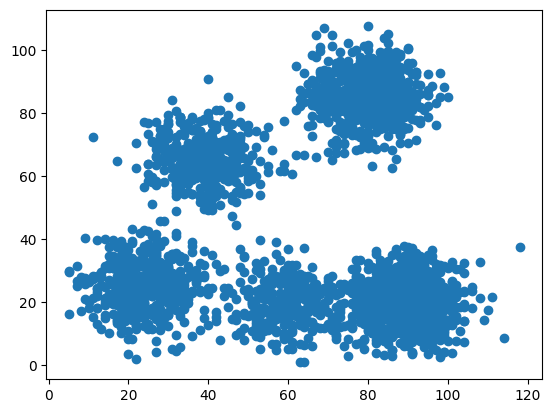

In [8]:
plt.scatter(df['Instagram visit score'] , df['Spending_rank(0 to 100)'])

In [49]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=4)
model.fit(df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [50]:
from sklearn.metrics import silhouette_score

silhouette_score(df , model.labels_)

0.6468250981862611

Text(0, 0.5, 'Spending_rank(0 to 100)')

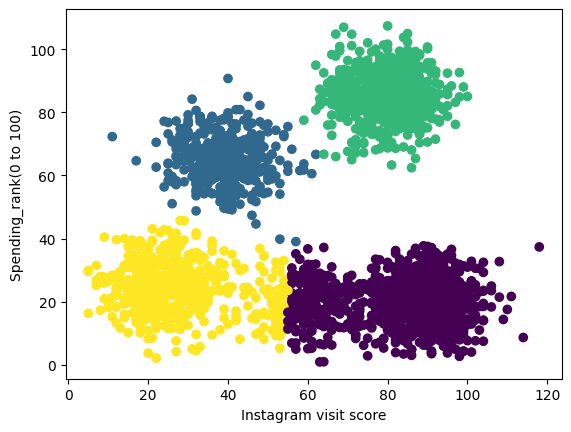

In [51]:
plt.scatter(df['Instagram visit score'] , df['Spending_rank(0 to 100)'] , c=model.labels_)
plt.xlabel("Instagram visit score")
plt.ylabel("Spending_rank(0 to 100)")

Text(0, 0.5, 'Silhouette Score')

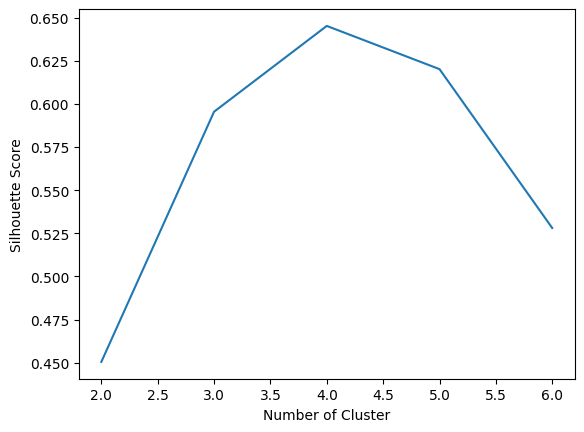

In [41]:
# Elbow method : 
inertia = []
sil = []
for k in range(2,7):
    model = KMeans(n_clusters=k)
    model.fit(df)
    inertia.append(model.inertia_)
    sil.append(silhouette_score(df , model.labels_))
l = [2,3,4,5,6]
plt.plot( l , sil)
plt.xlabel("Number of Cluster")
plt.ylabel("Silhouette Score")

In [53]:
df['group'] = model.labels_

In [54]:
df.head()

,Instagram visit score,Spending_rank(0 to 100),group
0,63,24.050708,0
1,61,25.223290,0
2,104,18.528245,0
3,82,86.890232,2
4,14,31.492397,3


In [55]:
df.group.unique()

array([0, 2, 3, 1], dtype=int32)

In [ ]:
df.replace({0:"high Vists and low spend time" , 1:"high Vists and hig